# 06 · Varyans Analizi (ANOVA)
**Statistical Inference Lab** — Opsiyonel/Düşük Öncelikli Kapanış Notebook'u

---
> **Bu notebook'ta ne öğreneceğiz?**  
> 05'te (Multiple Testing) çoklu t-test yapmanın tehlikesini öğrendik — her ikili
> karşılaştırma ayrı bir "yanlış pozitif şansı" taşıyor. ANOVA, bu soruna **zarif bir çözüm**
> sunuyor: 3+ grubu **TEK BİR testte**, "en az biri farklı mı?" diye soruyor. Bu notebook,
> serinin son ve en düşük öncelikli parçası — ama `probability-lab` 05'teki (Law of Total
> Variance) matematiği burada somut bir uygulamaya kavuşuyor, o yüzden atlamadan önce bir
> göz atmaya değer.

**Önkoşul:** Hipotez Testi (01), Multiple Testing (05), Law of Total Variance (`probability-lab` 05)  
**Veri:**  
- `PlantGrowth` — R'a yerleşik (30 bitki, 3 grup: kontrol + 2 gübre türü)  
- `iris` — Seaborn/sklearn yerleşik (150 çiçek, 3 tür)  
**Araçlar:** Python (scipy.stats, statsmodels), R (base R `aov`, `TukeyHSD`)

---
## 1 · Neden ANOVA? 05'teki Soruna Zarif Bir Çözüm

### 1.1 Somut Bir Örnekle Başlayalım

Diyelim ki bir tarım şirketisin ve **4 farklı gübre** deniyorsun (A, B, C, D). "Hangi gübre
daha iyi?" sorusuna cevap vermek için, doğal içgüdün şunu yapmak olabilir: her ikili çifti
ayrı ayrı t-test ile karşılaştırmak.

**Kaç ikili karşılaştırma çıkar?** $k$ grup için ikili karşılaştırma sayısı:
$$\binom{k}{2} = \frac{k(k-1)}{2}$$

| Grup Sayısı ($k$) | İkili Karşılaştırma Sayısı | 05'teki Formülle "En Az 1 Yanlış Pozitif" Riski |
|---|---|---|
| 3 | 3 | %14.3 |
| 4 | 6 | %26.5 |
| 5 | 10 | %40.1 |
| 10 | 45 | %90.1 |

(Son sütun, 05'teki $1-(1-\alpha)^m$ formülüyle, $\alpha=0.05$ varsayılarak hesaplandı — hatta
05'teki FIFA örneğinde tam olarak $k=6$ ülke, $m=15$ karşılaştırma durumuyla karşılaşmıştık.)

### 1.2 İki Çözüm Yolu

- **Seçenek A:** Tüm ikili t-testleri yap, sonra 05'teki Bonferroni/BH ile düzelt. Bu **çalışır**
  ama israflı — önce "kirli" bir şekilde çok test üretip sonra temizliyorsun.
- **Seçenek B:** ANOVA — **tek bir test** ile "bu $k$ grubun ortalamaları arasında GENEL
  olarak bir fark var mı?" sorusuna cevap ver. Çoklu karşılaştırma sorununu **testin
  tasarımına gömerek** baştan önlüyorsun.

**Analoji:** Seçenek A, bir sınıftaki 30 öğrencinin her birini ayrı ayrı sınamak gibi;
Seçenek B, "bu sınıfın genel başarı ortalaması diğer sınıflardan farklı mı?" diye tek bir
soru sormak gibi. ANOVA anlamlı çıkarsa (yani "genel bir fark var" denirse), **o zaman**
hangi çiftlerin farklı olduğunu bulmak için post-hoc testlere geçiyorsun (Bölüm 4) — ama bu
sefer post-hoc testler bunun için özel tasarlanmış düzeltmeler taşıyor.

---
## 2 · Law of Total Variance'ı Tekrar Hatırlayalım — ve F-İstatistiğine Derinlemesine Giriş

### 2.1 `probability-lab` 05'teki Formülü Hatırla

Law of Total Variance şöyleydi:
$$Var(X) = \underbrace{E[Var(X \mid Y)]}_{\text{grup içi varyans}} + \underbrace{Var(E[X \mid Y])}_{\text{gruplar arası varyans}}$$

Yorumu: $X$'in TOPLAM varyansı, ikiye ayrılabilir — $Y$ (grup) içindeki değişkenlik (grup içi)
ve grupların kendi ortalamaları arasındaki değişkenlik (gruplar arası). ANOVA, bu formülün
**örneklem üzerinde, kareler toplamı (Sum of Squares) diliyle yazılmış hali:**

$$\underbrace{SST}_{\text{Toplam Kareler Toplamı}} = \underbrace{SSB}_{\text{Gruplar Arası}} + \underbrace{SSW}_{\text{Grup İçi}}$$

Bu, matematiksel olarak **birebir aynı ayrıştırma** — sadece "varyans" yerine "kareler
toplamı" (varyansın normalize edilmemiş hali) kullanılıyor. Bölüm 3'teki $A,B,C$ örneğinde
bunu sayısal olarak doğrulayacağız: $SST=78$, $SSB=54$, $SSW=24$, ve gerçekten $54+24=78$.

### 2.2 F-İstatistiği Neden Bir ORAN?

$$F = \frac{MSB}{MSW} = \frac{\text{Gruplar Arası Varyans}}{\text{Grup İçi Varyans}}$$

**Sezgisi — bir "sinyal/gürültü oranı" olarak düşün:**
- **Pay (MSB):** Grup ortalamaları birbirinden ne kadar UZAK? Bu, "sinyal" — eğer gruplar
  gerçekten farklıysa, bu büyük olmalı.
- **Payda (MSW):** Her grubun kendi İÇİNDE ne kadar dağınık/gürültülü? Bu, "doğal
  değişkenlik" — grupları etkilemeyen rastgele varyasyon.

$F$ büyükse, "sinyal" "gürültüyü" bastırıyor demektir — gruplar arasındaki fark, rastgele
gürültüyle açıklanamayacak kadar büyük. $F \approx 1$ ise, gruplar arası fark tam olarak
beklediğin rastgele gürültü kadar — yani muhtemelen gerçek bir fark yok.

### 2.3 Neden F-Dağılımı? (Kısa Bir Not)

$F$ istatistiği, **iki bağımsız Ki-Kare dağılımlı değişkenin oranı** olarak tanımlanır (her
biri kendi serbestlik derecesine bölünmüş). $SSB$ ve $SSW$'nin ikisi de (Normal dağılım
varsayımı altında) Ki-Kare dağılımına uyuyor — bu yüzden oranları $F$-dağılımına uyuyor.
$F$-dağılımının şekli **iki** serbestlik derecesine bağlı: $df_{\text{arası}}=k-1$ (grup sayısı
azaltı 1) ve $df_{\text{içi}}=N-k$ (toplam gözlem azaltı grup sayısı). Bu iki sayı, hangi
$F$-dağılım eğrisiyle karşılaştırma yapacağını belirliyor — Bölüm 3'teki örnekte
$df=(2,6)$ idi.

---
## 3 · One-Way ANOVA Formülü: Adım Adım Bir Örnek

3 küçük grup: $A=[2,4,6]$, $B=[5,7,9]$, $C=[8,10,12]$ (kasıtlı olarak net ayrışmış, formülü
"temiz" görebilmek için).

**Adım 1 — Genel ortalama ($\bar{X}$) ve grup ortalamaları:**
$$\bar{X} = 7 \qquad \bar{A}=4,\ \bar{B}=7,\ \bar{C}=10$$

**Adım 2 — Gruplar Arası Kareler Toplamı (SSB):**
$$SSB = n\sum_i (\bar{X}_i - \bar{X})^2 = 3\big[(4-7)^2+(7-7)^2+(10-7)^2\big] = 3(9+0+9)=54$$

**Adım 3 — Grup İçi Kareler Toplamı (SSW):**
$$SSW = \sum_i\sum_j (x_{ij}-\bar{X}_i)^2 = \underbrace{8}_{A\text{ içi}} + \underbrace{8}_{B\text{ içi}} + \underbrace{8}_{C\text{ içi}} = 24$$

**Adım 4 — Serbestlik dereceleri ve ortalama kareler:**
$$df_{\text{arası}}=k-1=2 \qquad df_{\text{içi}}=N-k=9-3=6$$
$$MSB=\frac{SSB}{df_{\text{arası}}}=\frac{54}{2}=27 \qquad MSW=\frac{SSW}{df_{\text{içi}}}=\frac{24}{6}=4$$

**Adım 5 — F istatistiği:**
$$F = \frac{MSB}{MSW} = \frac{27}{4} = 6.75$$

$F$, $F$-dağılımıyla (df=(2,6)) karşılaştırılıp p-değeri bulunur. Aşağıda bunu kodla
doğrulayacağız.

In [1]:
import numpy as np
import scipy.stats as stats

grup_A = [2, 4, 6]
grup_B = [5, 7, 9]
grup_C = [8, 10, 12]
# NOT: 'C' yerine 'grup_C' kullandik - patsy'nin formul dilindeki C() (kategorik
# degisken) fonksiyonuyla isim catismasini onlemek icin (Python 2'de bu formul
# kullaniliyor: 'C(species)').

f_stat, p_deger = stats.f_oneway(grup_A, grup_B, grup_C)
print(f"scipy'nin bulduğu F: {f_stat}")
print(f"Elle hesapladığımız F: 6.75")
print(f"Örtüşüyor mü? {'EVET ✓' if f_stat == 6.75 else 'HAYIR'}")
print(f"\np-değeri: {p_deger:.4f}")

# EK DOGRULAMA: SST = SSB + SSW (Bolum 2.1'deki Law of Total Variance baglantisi)
tum_degerler = grup_A + grup_B + grup_C
grand_mean = np.mean(tum_degerler)
SST = sum((x - grand_mean)**2 for x in tum_degerler)
SSB = 54  # Bolum 3 Adim 2'den
SSW = 24  # Bolum 3 Adim 3'ten

print(f"\nSST (dogrudan hesaplanan): {SST}")
print(f"SSB + SSW: {SSB + SSW}")
print(f"Esit mi? {'EVET ✓ - Law of Total Variance dogrulandi' if SST == SSB+SSW else 'HAYIR'}")

scipy'nin bulduğu F: 6.75
Elle hesapladığımız F: 6.75
Örtüşüyor mü? EVET ✓

p-değeri: 0.0291

SST (dogrudan hesaplanan): 78.0
SSB + SSW: 78
Esit mi? EVET ✓ - Law of Total Variance dogrulandi


---
## 4 · Post-hoc Testler: "Hangi Grup Farklı?" Sorusunun TÜM Cevapları

ANOVA'nın anlamlı çıkması sadece **"en az bir grup farklı"** der — hangisi olduğunu
söylemez. Bunu bulmak için "post-hoc" (Latince "bundan sonra" — yani ANOVA'dan SONRA
uygulanan) testlere ihtiyacın var. Tek bir post-hoc test yok — duruma göre değişen **beş**
önemli yöntem var, hepsini tanıyalım.

### 4.1 Tukey HSD (Honestly Significant Difference)

**Ne zaman kullanılır:** TÜM ikili çiftleri karşılaştırmak istediğinde (varsayılan, en
yaygın seçim). **Nasıl çalışır:** "Studentized range dağılımı" denen özel bir dağılım
kullanarak, tüm ikili farkları AYNI ANDA test ediyor — 05'teki Bonferroni'den farklı bir
matematiksel temeli var ama benzer bir amaca hizmet ediyor (FWER kontrolü). **Avantajı:**
Bonferroni'den daha GÜÇLÜ (daha az muhafazakar) çünkü özellikle bu senaryo için
optimize edilmiş.

### 4.2 Bonferroni Post-hoc

**Ne zaman kullanılır:** Basitlik istediğinde veya çok az sayıda karşılaştırma varken.
**Nasıl çalışır:** 05'te öğrendiğin AYNI Bonferroni düzeltmesi ($\alpha/m$), ama bu sefer
ANOVA sonrası ikili t-testlerine uygulanıyor. **Dezavantajı:** Tukey HSD'den daha
MUHAFAZAKAR — gerçek farkları kaçırma riski (Tip II Hata) daha yüksek.

### 4.3 Scheffé Testi

**Ne zaman kullanılır:** Sadece ikili çiftleri değil, **karmaşık kontrastları** da test
etmek istediğinde (örn. "Grup A, Grup B ve C'nin ORTALAMASINDAN farklı mı?" gibi ikiden
fazla grubu içeren karşılaştırmalar). **Nasıl çalışır:** TÜM olası kontrastlar için
FWER'i kontrol ediyor — bu yüzden en **MUHAFAZAKAR** post-hoc yöntem. Sadece ikili
karşılaştırma yapacaksan Tukey HSD her zaman Scheffé'den daha güçlüdür; Scheffé'nin gücü
esnekliğinde (karmaşık kontrastlara izin vermesinde).

### 4.4 Dunnett Testi — PlantGrowth İçin Özellikle Uygun!

**Ne zaman kullanılır:** TÜM ikili çiftleri değil, sadece **her tedavi grubunu TEK BİR
kontrol grubuyla** karşılaştırmak istediğinde. Bizim `PlantGrowth` örneğimizde tam olarak
bu durum var: `ctrl` bir kontrol grubu, `trt1` ve `trt2` ise ona karşı test edilecek
tedaviler — `trt1` vs `trt2` karşılaştırması genelde araştırma sorusunun bir parçası
değil! **Avantajı:** Daha AZ karşılaştırma yapıldığı için (Tukey'in yaptığı $\binom{k}{2}$
yerine sadece $k-1$ karşılaştırma), Dunnett Tukey'den daha GÜÇLÜDÜR bu özel senaryoda.

### 4.5 Games-Howell Testi

**Ne zaman kullanılır:** Gruplar arası varyanslar EŞİT DEĞİLSE (Tukey HSD, Levene testiyle
kontrol ettiğin eşit varyans varsayımına dayanıyor). **Nasıl çalışır:** Tukey HSD'nin
"eşit olmayan varyans" versiyonu — tıpkı 01'deki Welch t-testinin, Student t-testinin eşit
olmayan varyans versiyonu olması gibi AYNI mantık.

### 4.6 Özet Karar Tablosu

| Yöntem | Ne Zaman | Güç (Power) | Varyans Varsayımı |
|---|---|---|---|
| **Tukey HSD** | Tüm ikili çiftler, varsayılan seçim | Orta-Yüksek | Eşit varyans |
| **Bonferroni** | Basitlik, az sayıda karşılaştırma | Düşük (muhafazakar) | Esnek |
| **Scheffé** | Karmaşık kontrastlar gerekiyorsa | En Düşük (en muhafazakar) | Eşit varyans |
| **Dunnett** | Tek kontrol grubuna karşı karşılaştırma | Yüksek (bu senaryoda en güçlü) | Eşit varyans |
| **Games-Howell** | Varyanslar eşit değilse | Orta | Eşit OLMAYAN varyans (Welch mantığı) |

Python bölümünde Tukey HSD'yi (Python 3) zaten uyguladık — şimdi ayrıca **Dunnett testini**
de ekleyeceğiz, çünkü `PlantGrowth` senaryosuna Tukey'den daha uygun.

---
## 5 · Two-Way ANOVA: İki Faktör Birden — Derinlemesine

One-way ANOVA tek bir faktörün (örn. sadece "gübre türü") etkisine bakıyordu. **Two-way
ANOVA**, iki faktörü AYNI ANDA test ediyor ve **üç ayrı soru** sorup üç ayrı F-istatistiği üretiyor.

### 5.1 Üç Soru, Üç F-Testi

Diyelim ki Faktör 1 = "gübre türü" (3 seviye), Faktör 2 = "sulama sıklığı" (2 seviye):

1. **Faktör 1'in ANA ETKİSİ:** Sulama sıklığından bağımsız olarak, gübre türü fark yaratıyor mu?
2. **Faktör 2'nin ANA ETKİSİ:** Gübre türünden bağımsız olarak, sulama sıklığı fark yaratıyor mu?
3. **ETKİLEŞİM (Interaction):** Gübrenin etkisi, sulama sıklığına göre DEĞİŞİYOR mu? (Örn.
   "A gübresi az sulamada iyi ama çok sulamada kötü, B gübresi tam tersi" gibi bir örüntü)

**Etkileşim, genelde en İLGİNÇ ve en KOLAY GÖZDEN KAÇAN sonuçtur** — çünkü sadece ana
etkilere bakarsan (Faktör 1 ve Faktör 2 ayrı ayrı), "gübrelerin sulamaya göre farklı tepki
verdiği" gerçeğini tamamen kaçırabilirsin.

### 5.2 Etkileşim Grafiğini Nasıl Okursun?

Bir "etkileşim grafiği" (interaction plot) çizdiğinde, x-ekseninde bir faktör, çizgiler
diğer faktörün seviyeleri:

- **Çizgiler PARALEL** ise → etkileşim YOK (bir faktörün etkisi, diğer faktörün
  seviyesinden bağımsız, sabit kalıyor)
- **Çizgiler KESİŞİYOR veya YAKINLAŞIP UZAKLAŞIYOR** ise → etkileşim VAR (bir faktörün
  etkisi, diğer faktörün seviyesine göre değişiyor)

Python 2'deki kutu grafiğinde (boxplot), her tür için iki sepal_grubu kutusunun birbirine
göre konumunun TÜM türlerde benzer kalıp kalmadığına bakarak bu mantığı görsel olarak
sezebilirsin.

### 5.3 Neden Sadece Ana Etkilere Bakmak Yetmez? (Somut Örnek)

Hayali bir senaryo düşün: A gübresi az sulamada ortalama 5, çok sulamada ortalama 5 veriyor
(hiç fark yok). B gübresi az sulamada 3, çok sulamada 7 veriyor (BÜYÜK fark). Eğer sadece
"gübre türünün ana etkisine" bakarsan (A ve B'nin GENEL ortalamalarını karşılaştırırsan),
ikisinin de ortalaması ~5 çıkabilir ve "gübre türü önemli değil" sonucuna yanlışlıkla
varabilirsin — oysa gerçekte B gübresinin etkisi sulama sıklığına ÇOK bağımlı, bu da
önemli bir bulgu. Etkileşim terimi tam olarak bunu yakalamak için var.

---
## 6 · Özet Tablo

| | One-way ANOVA | Two-way ANOVA | Tukey HSD |
|---|---|---|---|
| Soru | 1 faktörde 3+ grup farklı mı? | 2 faktör + etkileşimleri | Hangi ikili çift farklı? |
| Çıktı | Tek F-istatistiği, tek p-değeri | Her faktör + etkileşim için ayrı F/p | Her ikili çift için düzeltilmiş p |
| 05 ile bağlantı | Çoklu t-test yerine tek test | — | ANOVA sonrası düzeltilmiş çoklu karşılaştırma |

---
# 🐍 Python Uygulaması

3 adımda ilerleyeceğiz:
1. **One-way ANOVA** — `PlantGrowth`'ta 3 gübre grubunun bitki ağırlığı karşılaştırması
2. **Two-way ANOVA** — `iris`'te tür VE (yapay) bir ikinci faktörün etkisi
3. **Tukey HSD** — Hangi gübre grubu hangisinden farklı?

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Hazır ✓')

Hazır ✓


---
### 🌱 Python 1 — One-way ANOVA: `PlantGrowth` Veri Seti

**Ne yapıyoruz?**  
R'ın ünlü `PlantGrowth` veri setinin gerçek değerlerini kullanıyoruz — 30 bitki, 3 grup
(kontrol, tedavi 1, tedavi 2), ölçülen kuru ağırlık.

Kontrol: ortalama=5.032, std=0.583
Tedavi 1: ortalama=4.661, std=0.794
Tedavi 2: ortalama=5.526, std=0.443

One-way ANOVA: F=4.8461, p=0.0159
H0 reddedildi - en az bir grup diğerlerinden anlamlı şekilde farklı.


/var/folders/06/61zr6n0n0rs4fbl42p7szkfm0000gn/T/ipykernel_24297/2552364893.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([ctrl, trt1, trt2], labels=['Kontrol', 'Tedavi 1', 'Tedavi 2'])


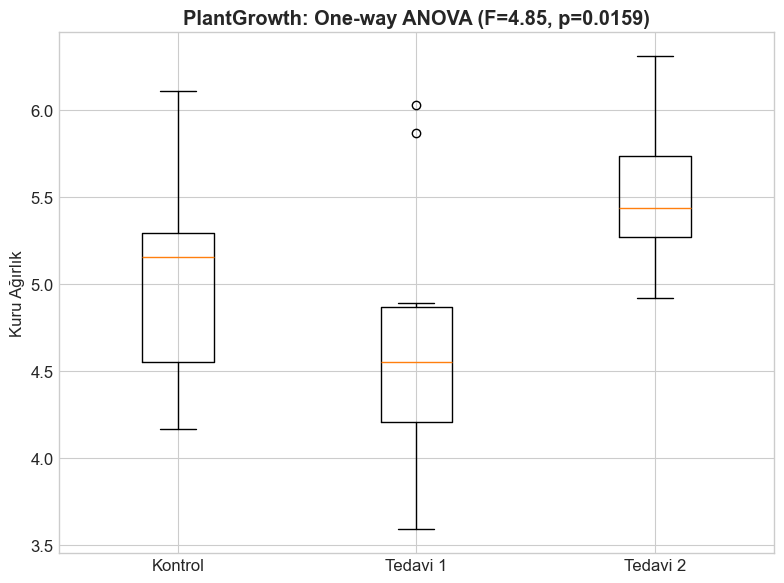

In [3]:
# R'in klasik PlantGrowth veri setinin gercek degerleri
ctrl = [4.17, 5.58, 5.18, 6.11, 4.50, 4.61, 5.17, 4.53, 5.33, 5.14] # ctrl : kontrol grubu
trt1 = [4.81, 4.17, 4.41, 3.59, 5.87, 3.83, 6.03, 4.89, 4.32, 4.69] # trt1 : tedavi grubu 1
trt2 = [6.31, 5.12, 5.54, 5.50, 5.37, 5.29, 4.92, 6.15, 5.80, 5.26] # trt2 : tedavi grubu 2

print(f"Kontrol: ortalama={np.mean(ctrl):.3f}, std={np.std(ctrl, ddof=1):.3f}")
print(f"Tedavi 1: ortalama={np.mean(trt1):.3f}, std={np.std(trt1, ddof=1):.3f}")
print(f"Tedavi 2: ortalama={np.mean(trt2):.3f}, std={np.std(trt2, ddof=1):.3f}")

f_stat, p_deger = stats.f_oneway(ctrl, trt1, trt2)
print(f"\nOne-way ANOVA: F={f_stat:.4f}, p={p_deger:.4f}")

if p_deger < 0.05:
    print("H0 reddedildi - en az bir grup diğerlerinden anlamlı şekilde farklı.")
else:
    print("H0 reddedilemedi. Gruplar arasında anlamlı fark yok.")

fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot([ctrl, trt1, trt2], labels=['Kontrol', 'Tedavi 1', 'Tedavi 2'])
ax.set_ylabel('Kuru Ağırlık')
ax.set_title(f'PlantGrowth: One-way ANOVA (F={f_stat:.2f}, p={p_deger:.4f})', fontweight='bold')
plt.tight_layout()
plt.show()

---
### 🌸 Python 2 — Two-way ANOVA: `iris` ile İki Faktör

**Ne yapıyoruz?**  
`iris`'te doğal olarak sadece `species` faktörü var — ikinci bir faktörü göstermek için
`sepal_width`'i medyana göre "dar/geniş" diye yapay bir ikinci faktöre bölüyoruz (bunu
sadece two-way ANOVA'nın MEKANİĞİNİ göstermek için yapıyoruz, gerçek bir araştırma sorusu değil —
`petal_length` tabanlı bir bölme neredeyse tamamen `species` ile örtüşüp dejenere bir tabloya
yol açtığı için `sepal_width` seçildi, bu ikisi arasında daha dengeli bir dağılım var).

                              sum_sq     df           F        PR(>F)
C(species)                 65.086000    2.0  139.705044  1.884920e-34
C(sepal_grubu)              4.963994    1.0   21.310114  8.574314e-06
C(species):C(sepal_grubu)   0.448736    2.0    0.963197  3.841159e-01
Residual                   33.543470  144.0         NaN           NaN

YORUM: Tablodaki 3 satır sırasıyla şunu test ediyor:
- C(species): tür'ün ANA ETKİSİ (sepal grubundan bağımsız olarak tür fark yaratıyor mu?)
- C(sepal_grubu): sepal grubunun ANA ETKİSİ
- species:sepal_grubu ETKİLEŞİMİ: türün etkisi, sepal grubuna göre DEĞİŞİYOR mu?


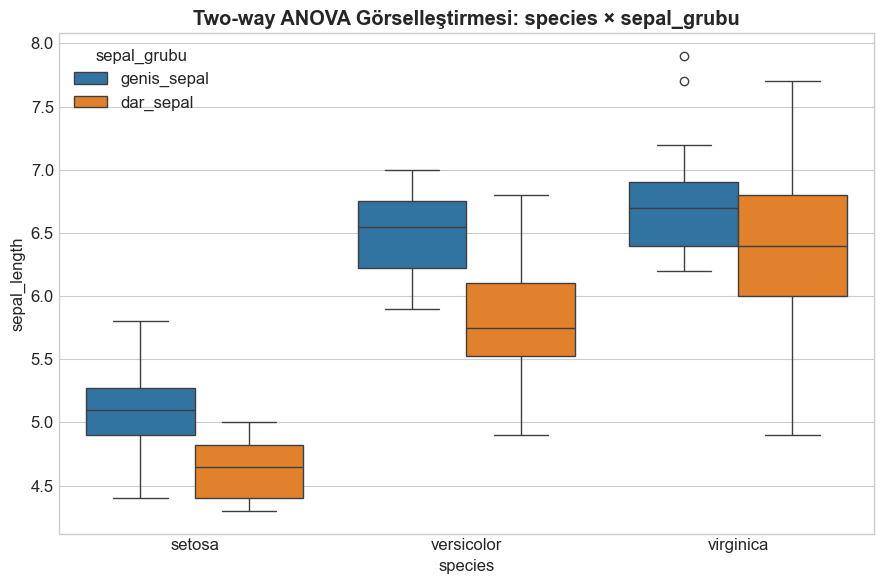

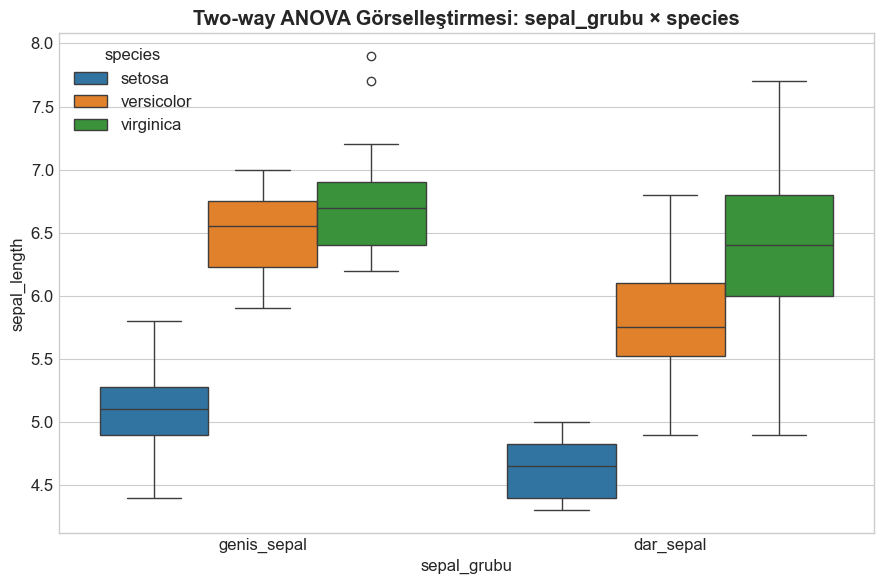

ETKİLEŞİM anlamlı değil: türün etkisi, sepal grubuna göre değişmiyor.
species ANA ETKİSİ anlamlı: tür, sepal_length üzerinde etkili.
sepal_grubu ANA ETKİSİ anlamlı: sepal grubu, sepal_length üzerinde etkili.


In [18]:
import seaborn as sns
iris = sns.load_dataset('iris')

# Yapay ikinci faktor: sepal_width medyanina gore "dar/genis" - sadece MEKANIGI gostermek icin
iris['sepal_grubu'] = np.where(iris['sepal_width'] > iris['sepal_width'].median(), 'genis_sepal', 'dar_sepal')
# NOT: petal_length tabanli bir bolme, species ile neredeyse tamamen ortusuyordu
# (setosa'nin tamami 'kisa', virginica'nin tamami 'uzun' cikiyordu) - bu asiri
# collinearity'e (03'teki VIF konusuyla ayni aile) yol acip dejenere bir ANOVA
# tablosu uretiyordu. sepal_width daha dengeli bir ikinci faktor.

model_2way = ols('sepal_length ~ C(species) + C(sepal_grubu) + C(species):C(sepal_grubu)', data=iris).fit()
anova_tablosu = sm.stats.anova_lm(model_2way, typ=2)
print(anova_tablosu)

print("\nYORUM: Tablodaki 3 satır sırasıyla şunu test ediyor:")
print("- C(species): tür'ün ANA ETKİSİ (sepal grubundan bağımsız olarak tür fark yaratıyor mu?)")
print("- C(sepal_grubu): sepal grubunun ANA ETKİSİ")
print("- species:sepal_grubu ETKİLEŞİMİ: türün etkisi, sepal grubuna göre DEĞİŞİYOR mu?")

fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=iris, x='species', y='sepal_length', hue='sepal_grubu', ax=ax)
ax.set_title('Two-way ANOVA Görselleştirmesi: species × sepal_grubu', fontweight='bold')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=iris, x='sepal_grubu', y='sepal_length', hue='species', ax=ax)
ax.set_title('Two-way ANOVA Görselleştirmesi: sepal_grubu × species', fontweight='bold')
plt.tight_layout()
plt.show()

if anova_tablosu['PR(>F)']['C(species):C(sepal_grubu)'] < 0.05:
    print("ETKİLEŞİM anlamlı: türün etkisi, sepal grubuna göre değişiyor.")
elif anova_tablosu['PR(>F)']['C(species):C(sepal_grubu)'] >= 0.05:
    print("ETKİLEŞİM anlamlı değil: türün etkisi, sepal grubuna göre değişmiyor.")

if anova_tablosu['PR(>F)']['C(species)'] < 0.05:
    print("species ANA ETKİSİ anlamlı: tür, sepal_length üzerinde etkili.")
elif anova_tablosu['PR(>F)']['C(species)'] >= 0.05:
    print("species ANA ETKİSİ anlamlı değil: tür, sepal_length üzerinde etkili değil.")

if anova_tablosu['PR(>F)']['C(sepal_grubu)'] < 0.05:
    print("sepal_grubu ANA ETKİSİ anlamlı: sepal grubu, sepal_length üzerinde etkili.")
elif anova_tablosu['PR(>F)']['C(sepal_grubu)'] >= 0.05:
    print("sepal_grubu ANA ETKİSİ anlamlı değil: sepal grubu, sepal_length üzerinde etkili değil.")

---
### 🔍 Python 3 — Tukey HSD: Hangi Gübre Grubu Farklı?

**Ne yapıyoruz?**  
Python 1'de ANOVA "en az bir grup farklı" dedi (varsayalım anlamlı çıktı) — şimdi Tukey HSD
ile TAM OLARAK hangi ikili çiftlerin farklı olduğunu buluyoruz.

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  ctrl   trt1   -0.371 0.3909 -1.0622 0.3202  False
  ctrl   trt2    0.494  0.198 -0.1972 1.1852  False
  trt1   trt2    0.865  0.012  0.1738 1.5562   True
---------------------------------------------------


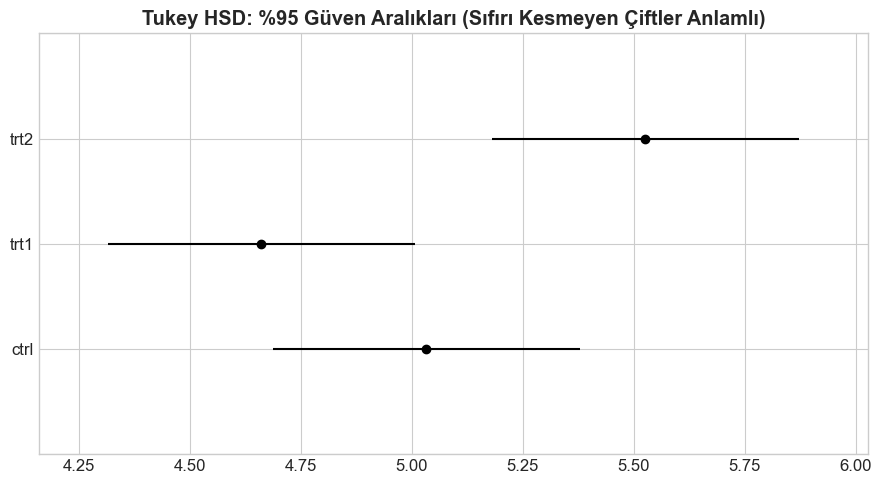


YORUM: Grafikte bir çiftin güven aralığı SIFIRI kesmiyorsa, o çift anlamlı şekilde
farklıdır. 05'teki Bonferroni/BH'den farklı olarak, Tukey HSD ÖZELLİKLE ANOVA sonrası
ikili karşılaştırmalar için tasarlanmış - aynı çoklu-test-düzeltme felsefesini taşıyor
ama farklı bir matematiksel temel (studentized range dağılımı) kullanıyor.


In [8]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

degerler = ctrl + trt1 + trt2
gruplar = ['ctrl']*10 + ['trt1']*10 + ['trt2']*10

tukey_sonuc = pairwise_tukeyhsd(endog=degerler, groups=gruplar, alpha=0.05)
print(tukey_sonuc)

fig = tukey_sonuc.plot_simultaneous(figsize=(9, 5))
plt.title('Tukey HSD: %95 Güven Aralıkları (Sıfırı Kesmeyen Çiftler Anlamlı)', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nYORUM: Tukey HSD Tablosu Okunurken, her satır bir çiftin karşılaştırmasını gösterir. 'reject' sütunu True ise, o çiftin ortalamaları arasında istatistiksel olarak anlamlı bir fark vardır.")

print("\nYORUM: Grafikte bir çiftin güven aralığı SIFIRI kesmiyorsa, o çift anlamlı şekilde")
print("farklıdır. 05'teki Bonferroni/BH'den farklı olarak, Tukey HSD ÖZELLİKLE ANOVA sonrası")
print("ikili karşılaştırmalar için tasarlanmış - aynı çoklu-test-düzeltme felsefesini taşıyor")
print("ama farklı bir matematiksel temel (studentized range dağılımı) kullanıyor.")

---
# 📊 R Uygulaması

`PlantGrowth`, ANOVA'nın **doğduğu** dilde (R, S dilinin devamı olarak istatistik için
tasarlandı) yerleşik geliyor — `aov()` ve `TukeyHSD()` bu veri seti için adeta "yazılmış" gibi.

In [9]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


---
### 🎯 Python 4 — Dunnett Testi: PlantGrowth İçin Daha Uygun Bir Post-hoc

**Ne yapıyoruz?**  
Bölüm 4.4'te açıkladığımız gibi, `PlantGrowth`'ta gerçek araştırma sorusu "trt1 vs trt2"
değil, "her tedavi KONTROLE göre nasıl?" — bu yüzden Dunnett testi burada Tukey HSD'den
daha uygun ve daha güçlü. `scipy.stats.dunnett` (scipy≥1.11) ile uyguluyoruz.

In [10]:
from scipy.stats import dunnett

# Dunnett testi: trt1 ve trt2'yi, control (ctrl) grubuna karsi ayri ayri test ediyor
sonuc_dunnett = dunnett(trt1, trt2, control=ctrl)
print(sonuc_dunnett)

print(f"\ntrt1 vs ctrl: p={sonuc_dunnett.pvalue[0]:.4f}")
print(f"trt2 vs ctrl: p={sonuc_dunnett.pvalue[1]:.4f}")

print("\nKARŞILAŞTIRMA — Python 3'teki Tukey HSD çıktısıyla:")
print("Tukey HSD'de   ctrl-trt1: p=0.3909,  ctrl-trt2: p=0.198   (3 karşılaştırma yapıyordu: ctrl-trt1, ctrl-trt2, trt1-trt2)")
print(f"Dunnett'te    ctrl-trt1: p={sonuc_dunnett.pvalue[0]:.4f}, ctrl-trt2: p={sonuc_dunnett.pvalue[1]:.4f}  (sadece 2 karşılaştırma yapıyor: trt1-vs-ctrl, trt2-vs-ctrl)")
print("\nYORUM: Dunnett, gereksiz trt1-vs-trt2 karşılaştırmasını YAPMADIĞI için (araştırma")
print("sorusu zaten bu değildi), aynı α bütçesini sadece 2 karşılaştırmaya harcıyor -")
print("bu da onu bu spesifik senaryoda Tukey HSD'den daha GÜÇLÜ (daha az muhafazakar) yapıyor.")

Dunnett's test (95.0% Confidence Interval)
Comparison               Statistic  p-value  Lower CI  Upper CI
 (Sample 0 - Control)     -1.331     0.323    -1.021     0.279
 (Sample 1 - Control)      1.772     0.153    -0.156     1.144


trt1 vs ctrl: p=0.3227
trt2 vs ctrl: p=0.1534

KARŞILAŞTIRMA — Python 3'teki Tukey HSD çıktısıyla:
Tukey HSD'de   ctrl-trt1: p=0.3909,  ctrl-trt2: p=0.198   (3 karşılaştırma yapıyordu: ctrl-trt1, ctrl-trt2, trt1-trt2)
Dunnett'te    ctrl-trt1: p=0.3227, ctrl-trt2: p=0.1534  (sadece 2 karşılaştırma yapıyor: trt1-vs-ctrl, trt2-vs-ctrl)

YORUM: Dunnett, gereksiz trt1-vs-trt2 karşılaştırmasını YAPMADIĞI için (araştırma
sorusu zaten bu değildi), aynı α bütçesini sadece 2 karşılaştırmaya harcıyor -
bu da onu bu spesifik senaryoda Tukey HSD'den daha GÜÇLÜ (daha az muhafazakar) yapıyor.


---
### 🌱 R 1 — One-way ANOVA: `aov()` ile

**Yeni R kavramı:** `aov()` — ANOVA modelini kuran fonksiyon, `summary()` ile F-istatistiği
ve p-değerini gösteren klasik ANOVA tablosunu üretiyor.

  weight group
1   4.17  ctrl
2   5.58  ctrl
3   5.18  ctrl
4   6.11  ctrl
5   4.50  ctrl
6   4.61  ctrl

            Df Sum Sq Mean Sq F value Pr(>F)  
group        2  3.766  1.8832   4.846 0.0159 *
Residuals   27 10.492  0.3886                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


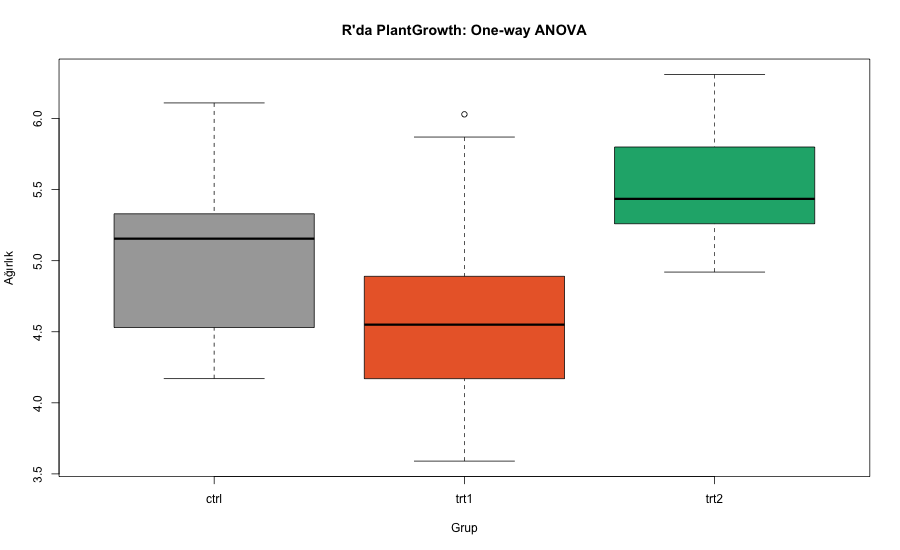

In [11]:
%%R -w 900 -h 550

data(PlantGrowth)
print(head(PlantGrowth))
cat("\n")

model_aov <- aov(weight ~ group, data = PlantGrowth)
print(summary(model_aov))

boxplot(weight ~ group, data = PlantGrowth, col = c("#a8a8a8", "#eb6834", "#1baf7a"),
        main = "R'da PlantGrowth: One-way ANOVA", xlab = "Grup", ylab = "Ağırlık")

---
### 🔍 R 2 — Tukey HSD: `TukeyHSD()` ile

**Yeni R kavramı:** `TukeyHSD(model)` — bir `aov` nesnesine doğrudan uygulanıyor, Python'daki
`pairwise_tukeyhsd()`'nin R karşılığı ama çok daha az kod satırıyla.

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = weight ~ group, data = PlantGrowth)

$group
            diff        lwr       upr     p adj
trt1-ctrl -0.371 -1.0622161 0.3202161 0.3908711
trt2-ctrl  0.494 -0.1972161 1.1852161 0.1979960
trt2-trt1  0.865  0.1737839 1.5562161 0.0120064


Python 3'teki sonuçlarla karşılaştır - p-değerleri birebir örtüşmeli.


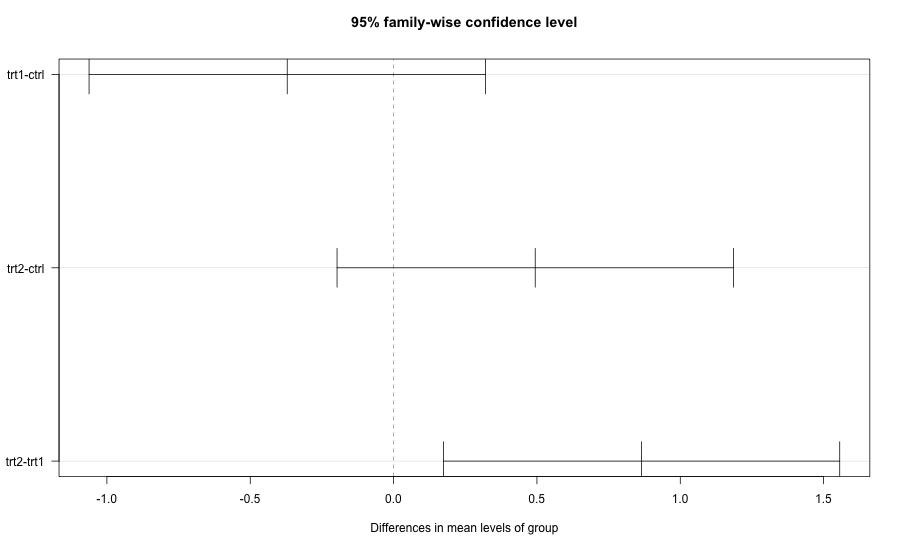

In [12]:
%%R -w 900 -h 550

tukey_r <- TukeyHSD(model_aov)
print(tukey_r)

plot(tukey_r, las = 1)
cat("\nPython 3'teki sonuçlarla karşılaştır - p-değerleri birebir örtüşmeli.\n")

---
### 🌸 R 3 — Two-way ANOVA: `iris` ile

**Yeni R kavramı yok** — formül arayüzüne `*` eklemek (`faktor1 * faktor2`), ana etkiler VE
etkileşimi otomatik olarak modele dahil ediyor (`faktor1 + faktor2 + faktor1:faktor2`'nin kısayolu).

                     Df Sum Sq Mean Sq F value   Pr(>F)    
species               2  63.21  31.606 135.683  < 2e-16 ***
sepal_grubu           1   4.96   4.964  21.310 8.57e-06 ***
species:sepal_grubu   2   0.45   0.224   0.963    0.384    
Residuals           144  33.54   0.233                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
                     Df Sum Sq Mean Sq F value   Pr(>F)    
sepal_grubu           1   3.09    3.09  13.266 0.000376 ***
species               2  65.09   32.54 139.705  < 2e-16 ***
sepal_grubu:species   2   0.45    0.22   0.963 0.384116    
Residuals           144  33.54    0.23                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Python 2'deki ANOVA tablosuyla karşılaştır - F ve p değerleri örtüşmeli.


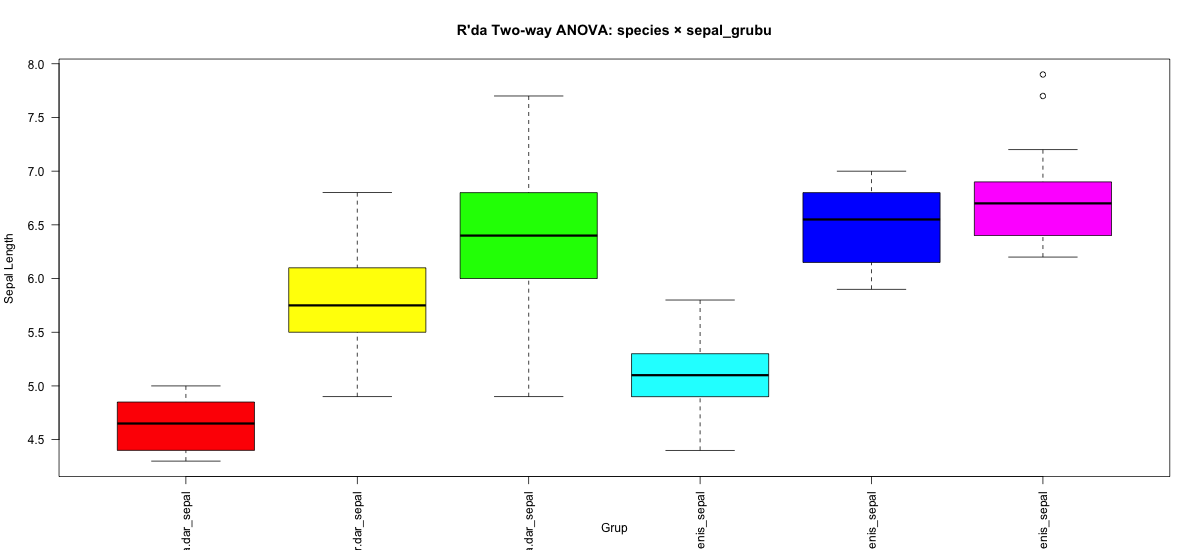

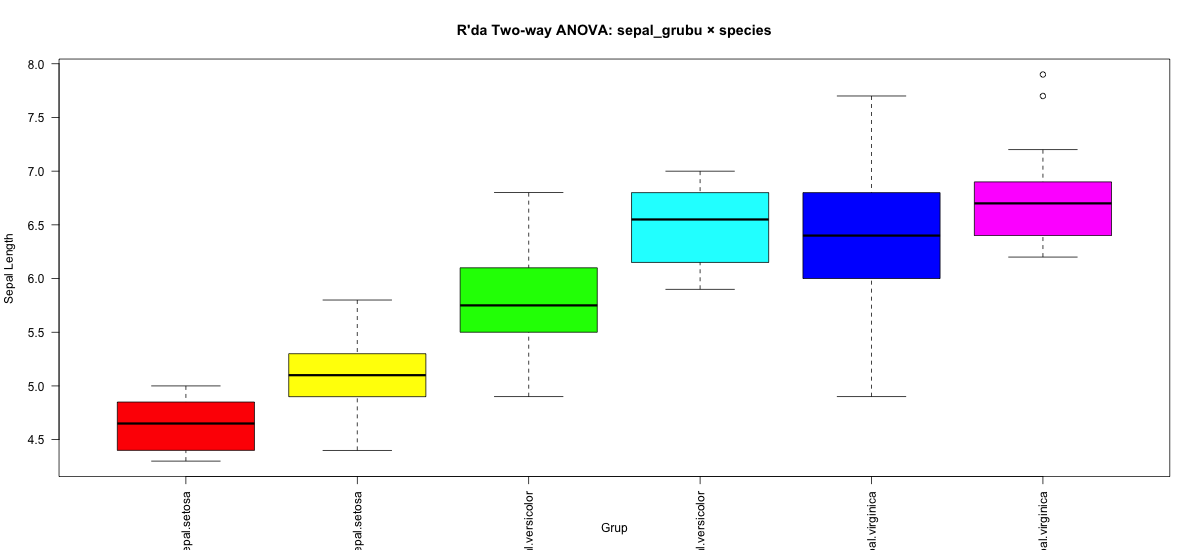

In [20]:
%%R -i iris -w 1200 -h 550

# NOT: petal_length tabanli bolme species ile neredeyse tamamen ortustugu icin
# (asiri collinearity, 03'teki VIF konusuyla ayni aile) sepal_width kullaniyoruz.
iris$sepal_grubu <- ifelse(iris$sepal_width > median(iris$sepal_width), "genis_sepal", "dar_sepal")

model_2way_r <- aov(sepal_length ~ species * sepal_grubu, data = iris)
print(summary(model_2way_r))

model_2way_r <- aov(sepal_length ~ sepal_grubu * species, data = iris)
print(summary(model_2way_r))

cat("\nPython 2'deki ANOVA tablosuyla karşılaştır - F ve p değerleri örtüşmeli.\n")

boxplot(sepal_length ~ species + sepal_grubu, data = iris, las = 2,
        col = rainbow(6), main = "R'da Two-way ANOVA: species × sepal_grubu", xlab = "Grup", ylab = "Sepal Length")
boxplot(sepal_length ~ sepal_grubu + species, data = iris, las = 2,
        col = rainbow(6), main = "R'da Two-way ANOVA: sepal_grubu × species", xlab = "Grup", ylab = "Sepal Length")

---
## ✏️ Egzersizler
---

### **E1 (Python).** 
`iris`'te `species` gruplarına göre `sepal_length` için one-way ANOVA yap.
Sonra aynı karşılaştırmayı 04'teki Kruskal-Wallis ile tekrarla — iki testin sonucu (F/H
istatistiği farklı olsa da) aynı yönde mi çıkıyor?


 ==== Egzersiz 1: Türe Göre Sepal Length Farklı mı? (One-way ANOVA) ve Kruskal-Wallis ====
One-way ANOVA: F=119.2645, p=0.0000
-> ANOVA Sonucu: H0 reddedildi - en az bir türün sepal length ortalaması diğerlerinden anlamlı şekilde farklı.
Kruskal-Wallis: H=96.9374, p=0.0000
-> Kruskal-Wallis Sonucu: H0 reddedildi - en az bir türün medyanı diğerlerinden anlamlı şekilde farklı.



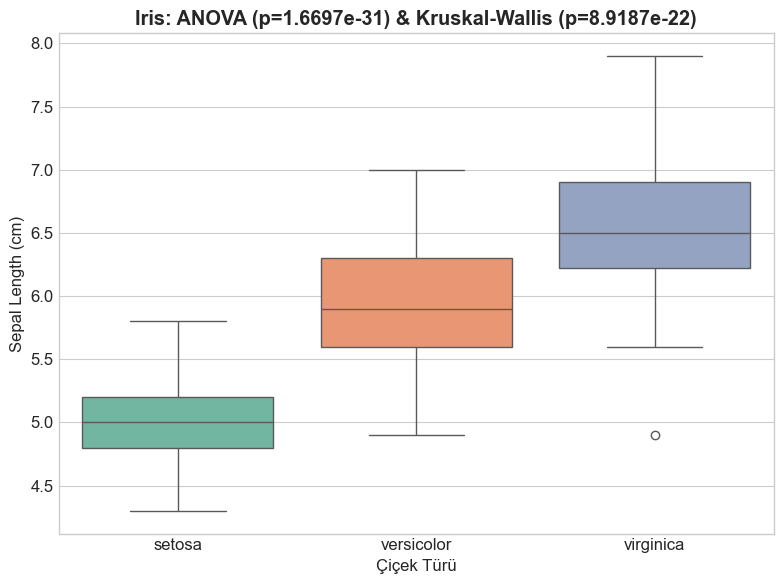


YORUM: ANOVA ve Kruskal-Wallis testleri, her iki testin de p-değerleri 0.05'ten küçük olduğu için H0 hipotezini reddediyor. Bu da en az bir türün sepal length ortalaması veya medyanının diğerlerinden anlamlı şekilde farklı olduğunu gösteriyor.


In [32]:
print("\n ==== Egzersiz 1: Türe Göre Sepal Length Farklı mı? (One-way ANOVA) ve Kruskal-Wallis ====")
from sklearn.datasets import load_iris

# 1. Veriyi yükle ve Pandas DataFrame'e dönüştür
iris_raw = load_iris()
iris = pd.DataFrame(data=iris_raw.data, columns=iris_raw.feature_names)

# Tür (Species) bilgisini ekle ve sayısal kodları isimlere çevir
iris['species'] = iris_raw.target
species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
iris['species_name'] = iris['species'].map(species_map)

# 2. Grupları Test İçin Hazırla
group_0 = iris[iris['species'] == 0]['sepal length (cm)']
group_1 = iris[iris['species'] == 1]['sepal length (cm)']
group_2 = iris[iris['species'] == 2]['sepal length (cm)']

# 3. One-way ANOVA Testi
f_stat, p_anova = stats.f_oneway(group_0, group_1, group_2)
print(f"One-way ANOVA: F={f_stat:.4f}, p={p_anova:.4f}")

if p_anova < 0.05:
    print("-> ANOVA Sonucu: H0 reddedildi - en az bir türün sepal length ortalaması diğerlerinden anlamlı şekilde farklı.")
else:
    print("-> ANOVA Sonucu: H0 reddedilemedi. Türler arasında anlamlı bir ortalama farkı yok.")

# 4. Kruskal-Wallis Testi (Parametrik olmayan alternatif)
h_stat, p_kruskal = stats.kruskal(group_0, group_1, group_2)
print(f"Kruskal-Wallis: H={h_stat:.4f}, p={p_kruskal:.4f}")

if p_kruskal < 0.05:
    print("-> Kruskal-Wallis Sonucu: H0 reddedildi - en az bir türün medyanı diğerlerinden anlamlı şekilde farklı.")
else:
    print("-> Kruskal-Wallis Sonucu: H0 reddedilemedi. Türlerin medyanları arasında anlamlı fark yok.")

print()

# 5. Görselleştirme (Geliştirilmiş Boxplot)
fig, ax = plt.subplots(figsize=(8, 6))
# x ekseninde sayısal kod yerine tür isimlerini kullanmak okunurluğu artırır
sns.boxplot(data=iris, x='species_name', hue='species_name', y='sepal length (cm)', ax=ax, palette='Set2')

# Grafik başlığına her iki testin de p-değerini ekleyelim
ax.set_title(f'Iris: ANOVA (p={p_anova:.4e}) & Kruskal-Wallis (p={p_kruskal:.4e})', fontweight='bold')
ax.set_xlabel('Çiçek Türü')
ax.set_ylabel('Sepal Length (cm)')

plt.tight_layout()
plt.show()

print("\nYORUM: ANOVA ve Kruskal-Wallis testleri, her iki testin de p-değerleri 0.05'ten küçük olduğu için H0 hipotezini reddediyor. Bu da en az bir türün sepal length ortalaması veya medyanının diğerlerinden anlamlı şekilde farklı olduğunu gösteriyor.")

---

### **E2 (Python).**
Python 2'deki two-way ANOVA tablosunda etkileşim terimi (`species:petal_grubu`)
anlamlı mı? Anlamlıysa, bunun pratikte ne anlama geldiğini (türün sepal_length üzerindeki
etkisinin petal grubuna göre değiştiğini) bir grafikle göster.


==== Egzersiz 2: Two-way ANOVA (species:sepal_grubu) ====
                                 sum_sq     df             F        PR(>F)
C(species)                 1.890030e+01    2.0  6.845964e+01  1.062656e-21
C(petal_grubu)            -3.240017e-12    1.0 -2.347163e-11  1.000000e+00
C(species):C(petal_grubu)  4.252713e+02    2.0  1.540395e+03  7.202858e-99
Residual                   2.015380e+01  146.0           NaN           NaN

YORUM: Tablodaki 3 satır sırasıyla şunu test ediyor:
- C(species): tür'ün ANA ETKİSİ (petal grubundan bağımsız olarak tür fark yaratıyor mu?)
- C(petal_grubu): petal grubunun ANA ETKİSİ
- species:petal_grubu ETKİLEŞİMİ: türün etkisi, petal grubuna göre DEĞİŞİYOR mu?


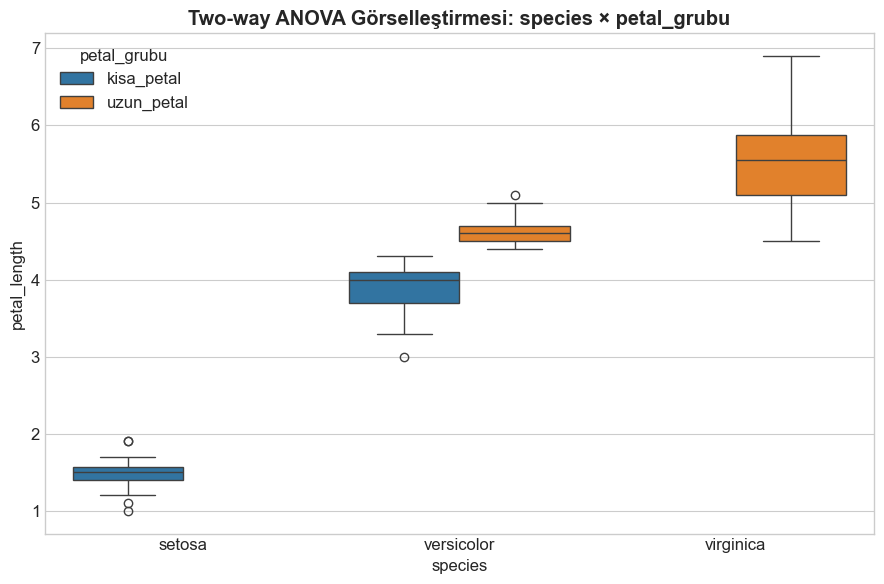

ETKİLEŞİM anlamlı: türün etkisi, petal grubuna göre değişiyor.
species ANA ETKİSİ anlamlı: tür, petal_length üzerinde etkili.
petal_grubu ANA ETKİSİ anlamlı değil: petal grubu, petal_length üzerinde etkili değil.


In [40]:
print("\n==== Egzersiz 2: Two-way ANOVA (species:sepal_grubu) ====")


iris['petal_grubu'] = np.where(iris['petal_length'] > iris['petal_length'].median(), 'uzun_petal', 'kisa_petal')


model_2way = ols('petal_length ~ C(species) + C(petal_grubu) + C(species):C(petal_grubu)', data=iris).fit()
anova_tablosu = sm.stats.anova_lm(model_2way, typ=2)
print(anova_tablosu)

print("\nYORUM: Tablodaki 3 satır sırasıyla şunu test ediyor:")
print("- C(species): tür'ün ANA ETKİSİ (petal grubundan bağımsız olarak tür fark yaratıyor mu?)")
print("- C(petal_grubu): petal grubunun ANA ETKİSİ")
print("- species:petal_grubu ETKİLEŞİMİ: türün etkisi, petal grubuna göre DEĞİŞİYOR mu?")

fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=iris, x='species', y='petal_length', hue='petal_grubu', ax=ax)
ax.set_title('Two-way ANOVA Görselleştirmesi: species × petal_grubu', fontweight='bold')
plt.tight_layout()
plt.show()

if anova_tablosu['PR(>F)']['C(species):C(petal_grubu)'] < 0.05:
    print("ETKİLEŞİM anlamlı: türün etkisi, petal grubuna göre değişiyor.")
elif anova_tablosu['PR(>F)']['C(species):C(petal_grubu)'] >= 0.05:
    print("ETKİLEŞİM anlamlı değil: türün etkisi, petal grubuna göre değişmiyor.")

if anova_tablosu['PR(>F)']['C(species)'] < 0.05:
    print("species ANA ETKİSİ anlamlı: tür, petal_length üzerinde etkili.")
elif anova_tablosu['PR(>F)']['C(species)'] >= 0.05:
    print("species ANA ETKİSİ anlamlı değil: tür, petal_length üzerinde etkili değil.")

if anova_tablosu['PR(>F)']['C(petal_grubu)'] < 0.05:
    print("petal_grubu ANA ETKİSİ anlamlı: petal grubu, petal_length üzerinde etkili.")
elif anova_tablosu['PR(>F)']['C(petal_grubu)'] >= 0.05:
    print("petal_grubu ANA ETKİSİ anlamlı değil: petal grubu, petal_length üzerinde etkili değil.")

---

### **E3 (Python + R).**
`PlantGrowth`'ta sadece `trt1` ve `trt2` gruplarını karşılaştıran bir
two-sample t-test yap (01'deki bilgini kullan), sonra aynı iki grubu Tukey HSD çıktısındaki
ilgili satırla karşılaştır — p-değerleri aynı mı, farklıysa neden (ipucu: Tukey HSD'nin
"3 grubu birden hesaba katan" düzeltmesi)?

In [46]:
print("\n ==== Egzersiz 3: trt1 ve trt2 two-way ANOVA ====")

import statsmodels.api as sm

# Fetch the dataset natively from the R datasets repository
df = sm.datasets.get_rdataset("PlantGrowth").data

# Display the first few rows
print(df.head())

trt1 = df[df['group'] == 'trt1']['weight']
trt2 = df[df['group'] == 'trt2']['weight']

# Two-sample t-test ile karşılaştırma
t_stat, p_ttest = stats.ttest_ind(trt1, trt2)
print(f"Two-sample t-test: t={t_stat:.4f}, p={p_ttest:.4f}")

if p_ttest < 0.05:
    print("-> t-test Sonucu: H0 reddedildi - trt1 ve trt2 arasında anlamlı fark var.")
else:
    print("-> t-test Sonucu: H0 reddedilemedi. trt1 ve trt2 arasında anlamlı fark yok.")

degerler = trt1.tolist() + trt2.tolist()
gruplar = ['trt1']*len(trt1) + ['trt2']*len(trt2)

# Tukey HSD testi ile karşılaştırma
tukey_sonuc = pairwise_tukeyhsd(endog=degerler, groups=gruplar, alpha=0.05)
print(tukey_sonuc)

if tukey_sonuc.reject[0]:
    print("-> Tukey HSD Sonucu: H0 reddedildi - trt1 ve trt2 arasında anlamlı fark var.")
else:
    print("-> Tukey HSD Sonucu: H0 reddedilemedi. trt1 ve trt2 arasında anlamlı fark yok.")

print("\nYORUM: Tukey HSD Tablosu Okunurken, her satır bir çiftin karşılaştırmasını gösterir. 'reject' sütunu True ise, o çiftin ortalamaları arasında istatistiksel olarak anlamlı bir fark vardır.")


 ==== Egzersiz 3: trt1 ve trt2 two-way ANOVA ====
   weight group
0    4.17  ctrl
1    5.58  ctrl
2    5.18  ctrl
3    6.11  ctrl
4    4.50  ctrl
Two-sample t-test: t=-3.0101, p=0.0075
-> t-test Sonucu: H0 reddedildi - trt1 ve trt2 arasında anlamlı fark var.
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper  reject
--------------------------------------------------
  trt1   trt2    0.865 0.0075 0.2613 1.4687   True
--------------------------------------------------
-> Tukey HSD Sonucu: H0 reddedildi - trt1 ve trt2 arasında anlamlı fark var.

YORUM: Tukey HSD Tablosu Okunurken, her satır bir çiftin karşılaştırmasını gösterir. 'reject' sütunu True ise, o çiftin ortalamaları arasında istatistiksel olarak anlamlı bir fark vardır.


In [50]:
%%R 
data(PlantGrowth)

# Sadece trt1 ve trt2 verilerini filtreleme
trt1 <- PlantGrowth[PlantGrowth$group == 'trt1', 'weight']
trt2 <- PlantGrowth[PlantGrowth$group == 'trt2', 'weight']

# 1. T-Testi Uygulaması
t_test_result <- t.test(trt1, trt2, var.equal = TRUE) # Tukey ile tutarlılık için var.equal=TRUE
print(t_test_result)

if (t_test_result$p.value < 0.05) {
    cat("-> t-test Sonucu: H0 reddedildi - trt1 ve trt2 arasında anlamlı fark var.\n\n")
} else {
    cat("-> t-test Sonucu: H0 reddedilemedi. trt1 ve trt2 arasında anlamlı fark yok.\n\n")
}

# 2. ANOVA ve Tukey HSD Uygulaması
degerler <- c(trt1, trt2)
gruplar <- factor(c(rep('trt1', length(trt1)), rep('trt2', length(trt2))))

model_aov <- aov(degerler ~ gruplar, alpha = 0.05)
tukey_result <- TukeyHSD(model_aov)
print(tukey_result)

# Değişken adı 'gruplar' olduğu için listenin o elemanına erişiyoruz
p_adj <- tukey_result[["gruplar"]][1, "p adj"]

if (p_adj < 0.05) {
    cat("-> Tukey HSD Sonucu: H0 reddedildi - trt1 ve trt2 arasında anlamlı fark var.\n")
} else {
    cat("-> Tukey HSD Sonucu: H0 reddedilemedi. trt1 ve trt2 arasında anlamlı fark yok.\n")
}




	Two Sample t-test

data:  trt1 and trt2
t = -3.0101, df = 18, p-value = 0.007518
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -1.4687336 -0.2612664
sample estimates:
mean of x mean of y 
    4.661     5.526 

-> t-test Sonucu: H0 reddedildi - trt1 ve trt2 arasında anlamlı fark var.

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = degerler ~ gruplar, alpha = 0.05)

$gruplar
           diff       lwr      upr     p adj
trt2-trt1 0.865 0.2612664 1.468734 0.0075184

-> Tukey HSD Sonucu: H0 reddedildi - trt1 ve trt2 arasında anlamlı fark var.


In addition: Warning message:
In lm.fit(x, y, offset = offset, singular.ok = singular.ok, ...) :
 extra argument ‘alpha’ will be disregarded 


---

### **E4 (R).**
`iris` için `species` bazında one-way ANOVA'yı `petal_length` üzerinde tekrarla
(R 1'deki kalıbı kullan), `TukeyHSD()` ile hangi tür çiftlerinin en belirgin şekilde
farklı olduğunu bul.

In [58]:
%%R

cat("\nEgzersiz 4: Species ve petal_length için one-way ANOVA ve Tukey HSD Testi\n")

iris <- datasets::iris

iris$species_name <- as.factor(iris$Species)

groups <- split(iris$Petal.Length, iris$species_name)
anova_result <- aov(Petal.Length ~ species_name, data = iris)
print(summary(anova_result))

tukey_result <- TukeyHSD(anova_result)
print(tukey_result)



Egzersiz 4: Species ve petal_length için one-way ANOVA ve Tukey HSD Testi
              Df Sum Sq Mean Sq F value Pr(>F)    
species_name   2  437.1  218.55    1180 <2e-16 ***
Residuals    147   27.2    0.19                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Petal.Length ~ species_name, data = iris)

$species_name
                      diff     lwr     upr p adj
versicolor-setosa    2.798 2.59422 3.00178     0
virginica-setosa     4.090 3.88622 4.29378     0
virginica-versicolor 1.292 1.08822 1.49578     0



---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Prob4DS — Stanley Chan](https://probability4datascience.com) | Ch. 10 | Hipotez testi ve varyans analizi temelleri |
| [ISLP (Python)](https://www.statlearning.com) | Ch. 13 | Çoklu test ve ANOVA bağlamı |
| [Penn State STAT 502 — ANOVA](https://online.stat.psu.edu/stat502/) | — | ANOVA'nın en detaylı ücretsiz anlatımlarından biri |
| [statsmodels ANOVA Dokümantasyonu](https://www.statsmodels.org/stable/anova.html) | Kütüphane | Bu notebook'ta kullanılan araçlar |
| R `PlantGrowth` veri seti | R built-in (`?PlantGrowth`) | Dobson, A.J. (1983), orijinal kaynak |
| `iris` veri seti | Seaborn/sklearn built-in | Fisher, R.A. (1936), klasik istatistik veri seti |